# Mobile UI Outline Viewer (Screenshot)
This notebook **draws an outline** over a social/mobile screenshot — headers, tab bars, content blocks, buttons, chips, and circular avatars/icons.


## 1) Install dependencies

In [1]:
!pip install opencv-python pillow numpy matplotlib


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Imports & basic helpers

In [2]:
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Dict

def load_bgr(path: str) -> np.ndarray:
    im = Image.open(path).convert('RGB')
    return cv2.cvtColor(np.array(im), cv2.COLOR_RGB2BGR)

def show_bgr(bgr, title=None, figsize=(8, 12)):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    if title: plt.title(title)
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()


## 3) Geometry helpers (IoU & NMS)

In [3]:
import numpy as np
from typing import List, Tuple

def rect_iou(a, b) -> float:
    ax1, ay1, ax2, ay2 = a; bx1, by1, bx2, by2 = b
    xi1, yi1 = max(ax1, bx1), max(ay1, by1)
    xi2, yi2 = min(ax2, bx2), min(ay2, by2)
    w, h = max(0, xi2 - xi1), max(0, yi2 - yi1)
    inter = w * h
    a_area = (ax2 - ax1) * (ay2 - ay1)
    b_area = (bx2 - bx1) * (by2 - by1)
    return inter / (a_area + b_area - inter + 1e-6)

def nms(boxes: List[Tuple[int,int,int,int]], scores: List[float], iou_thr=0.3):
    if not boxes: return [], []
    idx = np.argsort(scores)[::-1]
    keep = []
    while len(idx):
        i = idx[0]
        keep.append(i)
        rest = idx[1:]
        mask = []
        for j in rest:
            mask.append(rect_iou(boxes[i], boxes[j]) < iou_thr)
        idx = rest[np.array(mask, dtype=bool)]
    return [boxes[i] for i in keep], [scores[i] for i in keep]


## 4) Outline extraction & drawing

In [4]:
import cv2, numpy as np

def extract_outline(bgr):
    h, w = bgr.shape[:2]
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 7, 50, 50)

    edges = cv2.Canny(gray, 50, 140)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    edges_d = cv2.dilate(edges, k, iterations=1)

    contours, _ = cv2.findContours(edges_d, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    buttons, chips, blocks, headers, tabbars = [], [], [], [], []
    for cnt in contours:
        x,y,wc,hc = cv2.boundingRect(cnt)
        area = wc * hc
        if area < 400: continue
        rect = (x,y,x+wc,y+hc)

        perim = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.03*perim, True)
        rectangular = len(approx) in (4,5)

        ar = wc / (hc + 1e-6)
        fill_ratio = cv2.contourArea(cnt) / (area + 1e-6)

        if y < h*0.18 and wc > w*0.5 and 30 < hc < h*0.20:
            headers.append(rect); continue
        if y > h*0.75 and wc > w*0.5 and 30 < hc < h*0.20:
            tabbars.append(rect); continue

        if rectangular and area > (w*h)*0.01 and fill_ratio > 0.55:
            blocks.append(rect)

        if rectangular and 0.3 <= ar <= 6.0 and 400 <= area <= (w*h)*0.05:
            if 0.55 <= fill_ratio <= 0.95:
                buttons.append(rect)

        if rectangular and 1.4 <= ar <= 6.5 and 20 <= hc <= 70 and area <= (w*h)*0.015:
            chips.append(rect)

    avatars = []
    gb = cv2.GaussianBlur(gray, (7,7), 0)
    circles = cv2.HoughCircles(gb, cv2.HOUGH_GRADIENT, dp=1.2, minDist=max(20, h//40),
                               param1=80, param2=25,
                               minRadius=max(12, min(h,w)//60),
                               maxRadius=min(h,w)//10)
    if circles is not None:
        for c in circles[0, :]:
            cx, cy, r = int(c[0]), int(c[1]), int(c[2])
            avatars.append((cx - r, cy - r, cx + r, cy + r))

    def _prune(cat, weight=0.9):
        if not cat: return []
        scores = [ ((b[2]-b[0])*(b[3]-b[1]))**0.5 * weight for b in cat ]
        pruned, _ = nms(cat, scores, iou_thr=0.3)
        return pruned

    return {
        'headers': _prune(headers),
        'tabbars': _prune(tabbars),
        'blocks':  _prune(blocks),
        'buttons': _prune(buttons),
        'chips':   _prune(chips),
        'avatars': _prune(avatars),
    }

PALETTE = {
    'headers': (0, 180, 255),
    'tabbars': (0, 255, 255),
    'blocks':  (255, 170, 0),
    'buttons': (0, 255, 0),
    'chips':   (255, 0, 255),
    'avatars': (255, 0, 0),
}

def draw_outline(bgr, outline):
    out = bgr.copy()
    for key, boxes in outline.items():
        color = PALETTE.get(key, (200,200,200))
        for (x1,y1,x2,y2) in boxes:
            cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
            cv2.putText(out, key[:-1] if key.endswith('s') else key,
                        (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, color, 1, cv2.LINE_AA)
    h, w = out.shape[:2]
    for x in np.linspace(0, w, 4, dtype=int):
        cv2.line(out, (x,0), (x,h), (90,90,90), 1, cv2.LINE_AA)
    for y in np.linspace(0, h, 6, dtype=int):
        cv2.line(out, (0,y), (w,y), (90,90,90), 1, cv2.LINE_AA)
    return out


## 5) (Optional) List images in `/mnt/data`

In [ ]:
from glob import glob
files = sorted([p for ext in ('*.jpg','*.jpeg','*.png','*.webp') for p in glob(f'/mnt/data/{ext}')])
for f in files:
    print(f)
if not files:
    print('No images found in /mnt/data. Upload one or set an absolute path below.')


## 6) Run on your screenshot

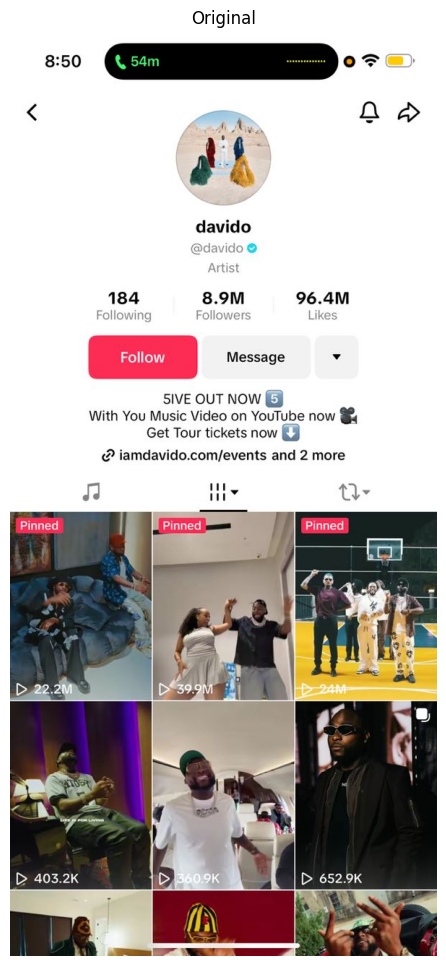

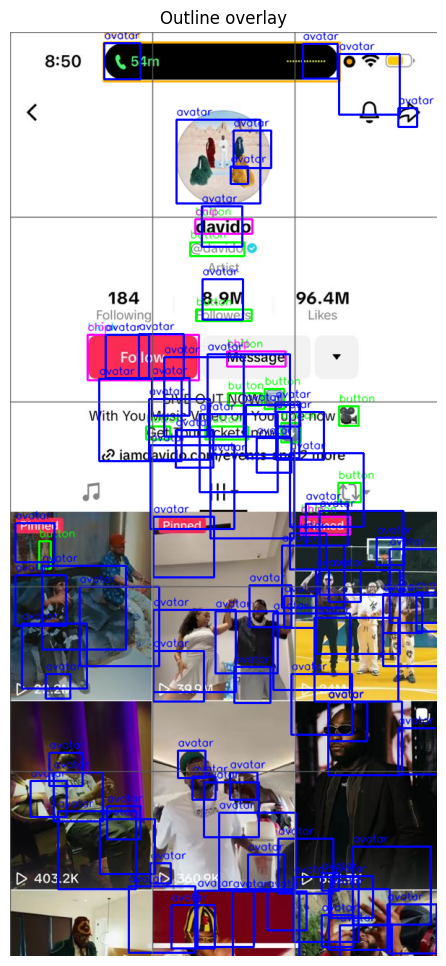

In [5]:
# Set your image path:
image_path = r'C:\Users\yemi\myratekard\veriry\WhatsApp Image 2025-10-13 at 8.51.21 PM.jpeg'  # e.g., '/mnt/data/WhatsApp Image 2025-10-13 at 8.51.25 PM.jpeg'

img = load_bgr(image_path)
outline = extract_outline(img)
overlay = draw_outline(img, outline)

show_bgr(img, 'Original')
show_bgr(overlay, 'Outline overlay')


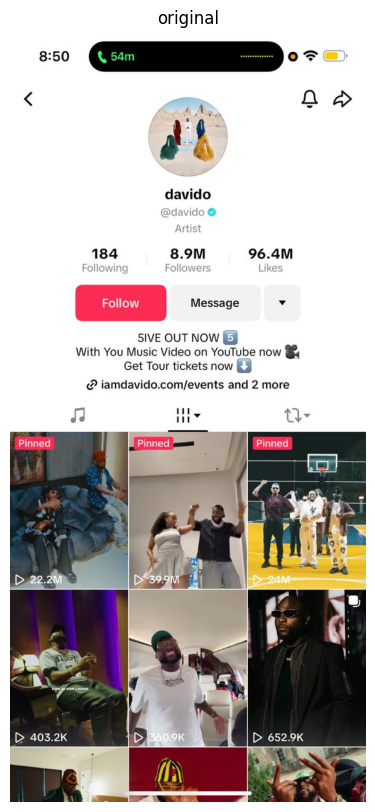

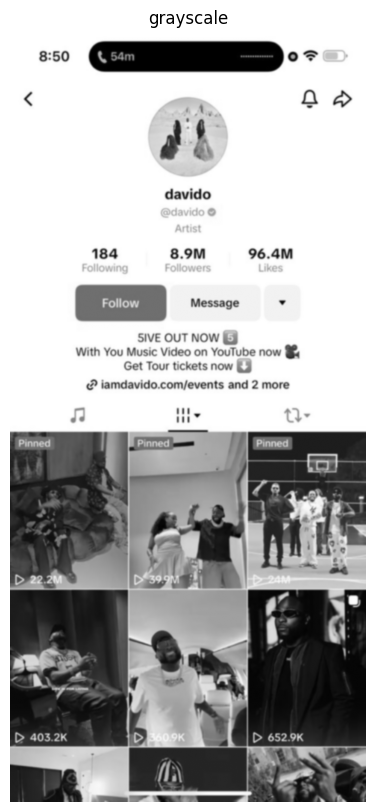

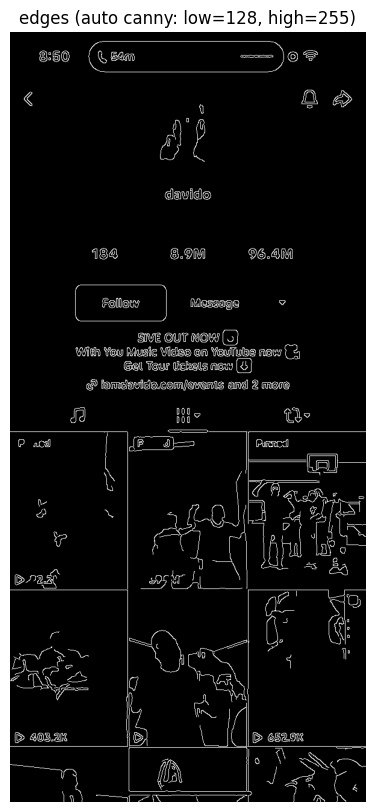

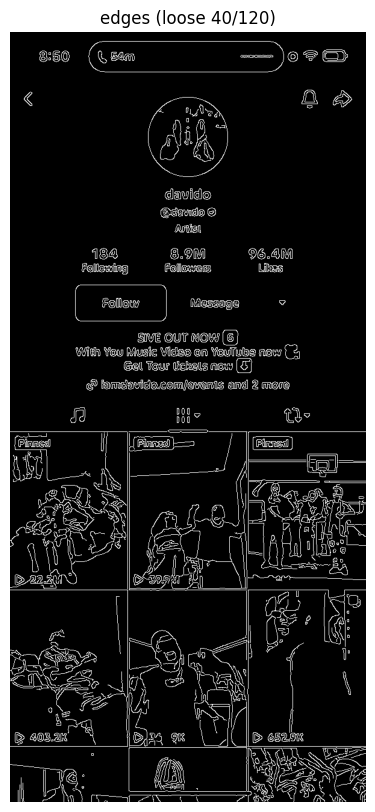

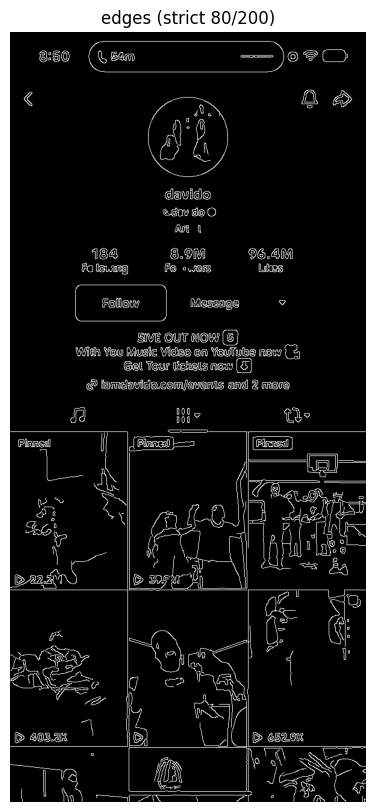

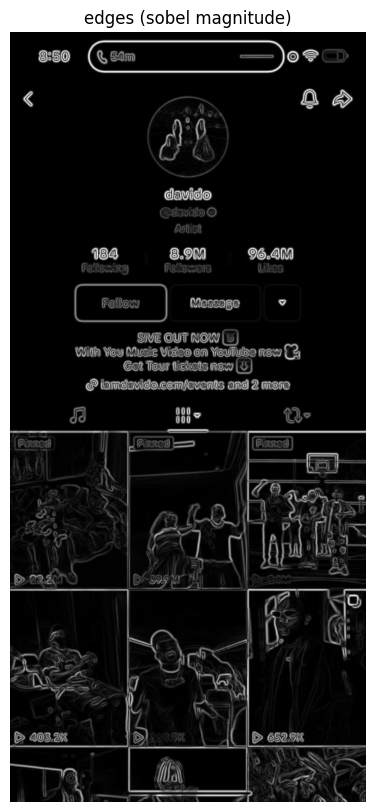

In [8]:
# --- minimal grayscale + edges viewer ---
# pip install opencv-python pillow matplotlib if you haven't
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# >>> change this to your file <<<
image_path = r"C:\Users\yemi\myratekard\veriry\WhatsApp Image 2025-10-13 at 8.51.21 PM.jpeg"

def load_bgr(path):
    return cv2.cvtColor(np.array(Image.open(path).convert("RGB")), cv2.COLOR_RGB2BGR)

def show(title, img, cmap=None, size=(6,10)):
    plt.figure(figsize=size); 
    if title: plt.title(title)
    if cmap: plt.imshow(img, cmap=cmap)
    else:    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off"); plt.show()

# 1) load
bgr = load_bgr(image_path)
show("original", bgr)

# 2) grayscale (with slight denoise for cleaner edges)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5,5), 0)     # comment out if you want raw gray
show("grayscale", gray, cmap="gray")

# 3) edges (Canny)
# auto thresholds based on image median for robust defaults
v = np.median(gray)
low  = int(max(0, 0.66 * v))
high = int(min(255, 1.33 * v))
edges_auto = cv2.Canny(gray, low, high, L2gradient=True)
show(f"edges (auto canny: low={low}, high={high})", edges_auto, cmap="gray")

# optional: manual thresholds if you want more/less edges
edges_loose  = cv2.Canny(gray, 20, 120, L2gradient=True)   # more edges
edges_strict = cv2.Canny(gray, 80, 200, L2gradient=True)   # fewer edges
show("edges (loose 40/120)", edges_loose, cmap="gray")
show("edges (strict 80/200)", edges_strict, cmap="gray")

# optional: Sobel magnitude (another edge flavor)
gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
mag = cv2.magnitude(gx, gy)
mag = (255 * (mag / (mag.max()+1e-6))).astype(np.uint8)
show("edges (sobel magnitude)", mag, cmap="gray")
